# Figure 8

In [1]:
import os
import sys

# Path to project root (works both in .py and .ipynb)
def get_project_root(levels_up=2):
    try:
        here = os.path.dirname(__file__)
    except NameError:
        here = os.getcwd()
    return os.path.abspath(os.path.join(here, *([".."] * levels_up)))

root_dir = get_project_root(2)
src_dir = os.path.join(root_dir, "src")

# Add src folder (parent of PyGhostID) to Python path
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

# Add paper folder
paper_dir = os.path.join(root_dir, "paper")
sys.path.insert(0, paper_dir)

# Import core as part of PyGhostID package
from PyGhostID import core as gid
print(gid.__file__)
import utils_paper as fun
print(fun.__file__)
import models_paper as mod

# other imports
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
import numpy as np
from scipy.integrate import solve_ivp
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import time


pylab.rcParams.update(fun.get_rcparams())
plt.rcParams.update({'font.family':'Arial'})

inCm = 1/2.54 # convert inch to cm for plotting


w:\GitHub\GhostID\src\PyGhostID\core.py
w:\GitHub\GhostID\paper\utils_paper.py


In [ ]:
# -------------------------
# Simulation worker
# -------------------------

def run_simulation_and_save(args):
    from models_paper import GRN_net

    ns, tl, rep_idx, seed, dt, outdir = args

    tl_sci = f"{tl:.0e}"
    fname = f"dataSim_N{ns}_TrjLen{tl_sci}_n{rep_idx:03d}.npy"
    fpath = os.path.join(outdir, fname)

    # Skip if already done
    if os.path.exists(fpath):
        return "skipped"

    t_end = tl * dt
    timesteps = np.linspace(0, t_end, int(tl))

    rng = np.random.default_rng(seed)
    np.random.seed(seed)

    G = nx.erdos_renyi_graph(ns, 0.15, directed=True, seed=seed)
    A = nx.to_numpy_array(G)

    # inhibitory edges
    p_inhibitory = 0.5
    mask = (A == 1) & (rng.random(A.shape) < p_inhibitory)
    A[mask] = -1

    parameters_GRN_net = [0.998, 0.25, 0.5, 0.5, 0.5, A]
    ic = rng.uniform(0, 1, ns)

    sol = solve_ivp(
        GRN_net,
        (0, t_end),
        ic,
        t_eval=timesteps,
        args=(parameters_GRN_net,),
        method="RK45",
    )

    # Save immediately and free memory
    np.save(fpath, sol.y.T.astype(np.float32))
    del sol

    return "saved"


# -------------------------
# Main execution
# -------------------------

if __name__ == "__main__":

    dt = 0.2
    network_size = [10, 25, 50, 100]
    Trj_length = [1e3, 5e3, 1e4, 5e4, 1e5, 5e5, 1e6]
    n_reps = 30

    # ---- Output directory ----
    base_dir = os.getcwd()
    outdir = os.path.join(base_dir, "data_simulations")
    os.makedirs(outdir, exist_ok=True)

    all_tasks = []
    seed = 0

    for ns in network_size:
        for tl in Trj_length:
            tl = int(tl)
            tl_sci = f"{tl:.0e}"

            # Count existing repetitions
            existing = [
                f for f in os.listdir(outdir)
                if f.startswith(f"dataSim_N{ns}_TrjLen{tl_sci}_")
            ]

            completed = len(existing)

            for rep_idx in range(completed, n_reps):
                seed += 500 + rep_idx
                all_tasks.append((ns, tl, rep_idx, seed, dt, outdir))

    print(f"Submitting {len(all_tasks)} simulations")

    with ThreadPoolExecutor(max_workers=10) as executor:
        futures = [executor.submit(run_simulation_and_save, task)
                   for task in all_tasks]

        for _ in tqdm(as_completed(futures),
                      total=len(futures),
                      desc="Running simulations",
                      unit="sim"):
            pass


In [ ]:
network_size = [10, 25, 50, 100]
Trj_length = [1e3, 5e3, 1e4, 5e4, 1e5, 5e5, 1e6]
seed=0
for ns in network_size:
        for tl in Trj_length:
                seed += 500
print(seed)

In [ ]:
import os
import numpy as np
import networkx as nx
from tqdm import tqdm

# -------------------------
# Configuration
# -------------------------

network_size = [10, 25, 50, 100]
Trj_length = [1e3, 5e3, 1e4, 5e4, 1e5, 5e5, 1e6]
n_reps = 30

p_edge = 0.15
p_inhibitory = 0.5

# -------------------------
# Output directory
# -------------------------

base_dir = os.getcwd()
adj_dir = os.path.join(base_dir, "data_adjacency_matrices")
os.makedirs(adj_dir, exist_ok=True)

# -------------------------
# Seed logic (INTENTIONALLY order-dependent)
# -------------------------

seed = 0

total = len(network_size) * len(Trj_length) * n_reps

with tqdm(total=total, desc="Generating adjacency matrices", unit="A") as pbar:
    for ns in network_size:
        for tl in Trj_length:
            tl = int(tl)
            tl_sci = f"{tl:.0e}"

            for rep_idx in range(n_reps):
                seed += 500 + rep_idx  # ← exactly your logic

                fname = f"adjMat_N{ns}_TrjLen{tl_sci}_n{rep_idx:03d}.npy"
                fpath = os.path.join(adj_dir, fname)

                # Skip if already exists (restart-safe)
                if os.path.exists(fpath):
                    pbar.update(1)
                    continue

                rng = np.random.default_rng(seed)

                G = nx.erdos_renyi_graph(
                    ns,
                    p_edge,
                    directed=True,
                    seed=seed
                )

                A = nx.to_numpy_array(G, dtype=np.int8)

                # Inhibitory edges
                mask = (A == 1) & (rng.random(A.shape) < p_inhibitory)
                A[mask] = -1

                np.save(fpath, A)

                pbar.update(1)

print("Adjacency matrix generation complete.")


In [3]:
import os
import time
import gc
import numpy as np

# -------------------------
# Configuration
# -------------------------

network_size = [10, 25, 50, 100]
Trj_length = [1e3, 5e3, 1e4, 5e4, 1e5, 5e5, 1e6]
n_reps = 30
dt = 0.2

base_dir = os.getcwd()
traj_dir = os.path.join(base_dir, "data_simulations")
adj_dir = os.path.join(base_dir, "data_adjacency_matrices")

runtime_file = os.path.join(base_dir, "runtimes_ghostID.npy")

# -------------------------
# Initialize / load runtime array
# -------------------------

if os.path.exists(runtime_file):
    runtimes_ghostID = np.load(runtime_file)
else:
    runtimes_ghostID = np.full(
        (len(network_size), len(Trj_length), n_reps),
        np.nan,
        dtype=np.float64,
    )
    np.save(runtime_file, runtimes_ghostID)

# -------------------------
# Sequential processing
# -------------------------

for i, ns in enumerate(network_size):
    for j, tl in enumerate(Trj_length):
        tl_sci = f"{int(tl):.0e}"

        for k in tqdm(range(n_reps)):

            # if not np.isnan(runtimes_ghostID[i, j, k]):
            #     continue

            traj_fname = f"dataSim_N{ns}_TrjLen{tl_sci}_n{k:03d}.npy"
            traj_path = os.path.join(traj_dir, traj_fname)

            adj_fname = f"adjMat_N{ns}_TrjLen{tl_sci}_n{k:03d}.npy"
            adj_path  = os.path.join(adj_dir, adj_fname)

            if not (os.path.exists(traj_path) and os.path.exists(adj_path)):
                continue

            # ---- Load ONE trajectory + adjacency ----
            Trj = np.load(traj_path, mmap_mode="r")
            A   = np.load(adj_path)

            # ---- Time processing (DUMMY PLACEHOLDER) ----
            start = time.perf_counter()

            # >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>

            parameters_GRN_net = parameters_GRN_net = [0.998,0.25,0.5,0.5,0.5,A]

            start = time.perf_counter()
            ghostSeq = gid.ghostID(
                mod.GRN_net,
                parameters_GRN_net,
                dt,
                Trj,
                0.015,
                evLimit=0.03,
                eigval_NN_sorting = True,
                peak_kwargs={"prominence": 2, "width": 50 * dt},
                display_warnings = True,
                ctrlOutputs={"ctrl_qplot":False,"qplot_xscale":"log","ctrl_evplot":False}
            )
            # time.sleep(0.001)
            # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

            end = time.perf_counter()

            runtimes_ghostID[i, j, k] = end - start
            np.save(runtime_file, runtimes_ghostID)

            # ---- Free memory ----
            del Trj, A
            gc.collect()

print("Runtime evaluation complete.")
print("runtimes_ghostID shape:", runtimes_ghostID.shape)


  0%|          | 0/30 [00:00<?, ?it/s]

 13%|█▎        | 4/30 [00:03<00:22,  1.13it/s]

Error in evaluating sign change of eigenvalues: monotonicity violated. 


 83%|████████▎ | 25/30 [00:39<00:04,  1.01it/s]

GhostID: Trajectory does not leave U_eps - stopping ghostID.


...

ghostID error: insuffienct number of points in Ueps!


 83%|████████▎ | 25/30 [03:58<00:48,  9.63s/it]

ghostID error: insuffienct number of points in Ueps!


100%|██████████| 30/30 [04:46<00:00,  9.54s/it]

Runtime evaluation complete.
runtimes_ghostID shape: (4, 7, 30)


In [ ]:
# import os
# import numpy as np

# network_size = [10, 25, 50, 100]
# Trj_length = [1e3, 5e3, 1e4, 5e4, 1e5, 5e5, 1e6]
# n_reps = 30

# simulation_results = [
#     [
#         [None for _ in range(n_reps)]
#         for _ in range(len(Trj_length))
#     ]
#     for _ in range(len(network_size))
# ]

# base_dir = os.getcwd()
# outdir = os.path.join(base_dir, "data_simulations")

# for i, ns in enumerate(network_size):
#     for j, tl in enumerate(Trj_length):
#         tl_sci = f"{int(tl):.0e}"

#         for k in range(n_reps):
#             fname = f"dataSim_N{ns}_TrjLen{tl_sci}_n{k:03d}.npy"
#             fpath = os.path.join(outdir, fname)

#             if os.path.exists(fpath):
#                 simulation_results[i][j][k] = np.load(fpath)
#             else:
#                 simulation_results[i][j][k] = None

# print("Loaded simulation_results with structure:")
# print(f"[network_size={len(network_size)}]"
#       f"[Trj_length={len(Trj_length)}]"
#       f"[n_reps={n_reps}]")

In [ ]:
# def run_simulation(args):
#     from models_paper import GRN_net
    
#     ns, tl, seed, dt = args

#     t_end = tl * dt
#     timesteps = np.linspace(0, t_end, int(tl))

#     rng = np.random.default_rng(seed)
#     np.random.seed(seed)

#     G = nx.erdos_renyi_graph(ns, 0.15, directed=True, seed=seed)
#     A = nx.to_numpy_array(G)

#     p_inhibitory = 0.5
#     for i in range(A.shape[0]):
#         for j in range(A.shape[1]):
#             if A[i, j] == 1 and rng.random() < p_inhibitory:
#                 A[i, j] = -1

#     parameters_GRN_net = [0.998, 0.25, 0.5, 0.5, 0.5, A]

#     ic = np.random.uniform(0, 1, ns)

#     sol = solve_ivp(
#         GRN_net,
#         (0, t_end),
#         ic,
#         t_eval=timesteps,
#         args=(parameters_GRN_net,),
#         method="RK45",
#     )

#     return {
#         "Trj": sol.y.T,
#         "parameters": parameters_GRN_net,
#         "error": None,
#     }

# # -------------------------
# # Main execution
# # -------------------------

# if __name__ == "__main__":

#     # =========
#     # 1) Parallel simulations
#     # =========

#     dt=0.2
#     network_size = [10,25,50,100]
#     Trj_length = [1e3, 5e3, 1e4, 5e4, 1e5, 5e5, 1e6]
#     n_reps = 30

#     simulation_results = []

#     # Flatten all tasks into a single list
#     seed = 0
#     all_tasks = []
#     for ns in network_size:
#         for tl in Trj_length:
#             for n in range(n_reps):
#                 seed = seed + 500 + n
#                 all_tasks.append((ns, int(tl), seed, dt))

#     # Map each task to its corresponding indices to reconstruct the nested structure later
#     task_indices = [(i, j, k) for i, ns in enumerate(network_size)
#                             for j, tl in enumerate(Trj_length)
#                             for k in range(n_reps)]

#     # Prepare nested storage
#     simulation_results = [[[None for _ in range(n_reps)]
#                         for _ in range(len(Trj_length))]
#                         for _ in range(len(network_size))]

#     with ThreadPoolExecutor(max_workers=10) as executor:
#         futures = {executor.submit(run_simulation, arg): idx for arg, idx in zip(all_tasks, task_indices)}

#         for f in tqdm(as_completed(futures), total=len(futures),
#                     desc="Running simulations", unit="sim"):
#             result = f.result()
#             i, j, k = futures[f]
#             simulation_results[i][j][k] = result

    

In [ ]:
# # =========
# # 2) ghostID processing + timing
# # =========
# ghostID_runtimes = []

# for ns_results in simulation_results:
#     ns_times = []
#     for tl_results in ns_results:
#         tl_times = []
#         for result in tl_results:
#             Trj = result["Trj"]
#             parameters_GRN_net = result["parameters"]

#             start = time.perf_counter()
#             ghostSeq = gid.ghostID(
#                 mod.GRN_net,
#                 parameters_GRN_net,
#                 dt,
#                 Trj,
#                 0.015,
#                 evLimit=0.03,
#                 eigval_NN_sorting = True,
#                 peak_kwargs={"prominence": 2, "width": 50 * dt},
#                 display_warnings = False
#             )
#             end = time.perf_counter()

#             tl_times.append(end - start)
#         ns_times.append(tl_times)
#     ghostID_runtimes.append(ns_times)

# ghostID_runtimes = np.asarray(ghostID_runtimes)

# print("ghostID_runtimes shape:", ghostID_runtimes.shape)
# np.save("data_runtimes.npy",ghostID_runtimes)

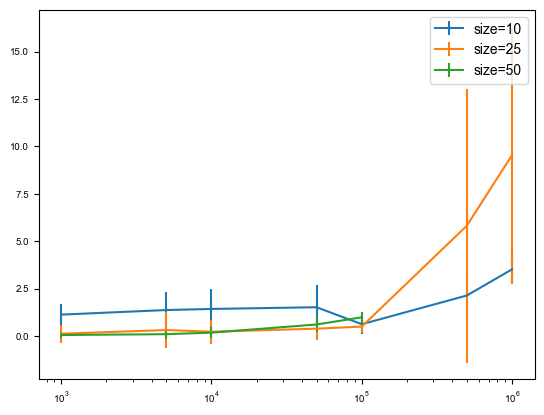

In [8]:
network_size = [10,25,50]#,100]
Trj_length = [1e3, 5e3, 1e4, 5e4, 1e5, 5e5, 1e6]
n_reps = 30


try: ghostID_runtimes = np.load("runtimes_ghostID.npy")
except: print("Loading of runtimes failed.")

# print(ghostID_runtimes)
for i in range(len(network_size)):
    avg = np.mean(ghostID_runtimes[i,:,:],axis=1)
    sd = np.std(ghostID_runtimes[i,:,:],axis=1)
    # plt.figure()
    plt.errorbar(Trj_length,avg,yerr=sd, label=f"size={network_size[i]}")

plt.xscale('log')
plt.legend()

In [ ]:
def run_simulation(args):
    from models_paper import GRN_net
    
    A, tl, seed, dt = args

    t_end = tl * dt
    timesteps = np.linspace(0, t_end, int(tl))
    
    parameters_GRN_net = [0.998, 0.25, 0.5, 0.5, 0.5, A]

    rng = np.random.default_rng(seed)
    ic = np.random.uniform(0, 1, A.shape[0])

    sol = solve_ivp(
        GRN_net,
        (0, t_end),
        ic,
        t_eval=timesteps,
        args=(parameters_GRN_net,),
        method="RK45",
    )

    return sol.y.T

# -------------------------
# Main execution
# -------------------------

if __name__ == "__main__":

    # =========
    # 1) Parallel simulations
    # =========

    n = 12
    seed = 135   

    rng = np.random.default_rng(seed)
    np.random.seed(seed)

    G = nx.erdos_renyi_graph(n, 0.15, directed=True, seed=seed)
    A = nx.to_numpy_array(G)

    p_inhibitory = 0.5
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            if A[i, j] == 1 and rng.random() < p_inhibitory:
                A[i, j] = -1


    dt=0.2
    Trj_length = [1e3, 5e3, 1e4, 5e4, 1e5, 5e5, 1e6]
    n_reps = 30

    simulation_results = []

    # Flatten all tasks into a single list
    all_tasks = []

    seed = 1000
    for i in range(len(Trj_length)):
        for n in range(n_reps):
            seed = seed + 1000 * i + n
            all_tasks.append((A, int(Trj_length[i]), seed, dt))

    # Map each task to its corresponding indices to reconstruct the nested structure later
    task_indices = [(j, k)  for j, tl in enumerate(Trj_length)
                            for k in range(n_reps)]

    # Prepare nested storage
    simulation_results = [[None for _ in range(n_reps)]
                      for _ in range(len(Trj_length))]

    with ThreadPoolExecutor(max_workers=10) as executor:
        futures = {executor.submit(run_simulation, arg): idx for arg, idx in zip(all_tasks, task_indices)}

        for f in tqdm(as_completed(futures), total=len(futures),
                    desc="Running simulations", unit="sim"):
            result = f.result()
            j, k = futures[f]
            simulation_results[j][k] = result

    

In [ ]:
# =========
# 2) ghostID processing + timing
# =========
ghostID_runtimes = []

for tl_results in simulation_results:
    tl_times = []
    for result in tl_results:
        Trj = result["Trj"]
        parameters_GRN_net = result["parameters"]

        start = time.perf_counter()
        ghostSeq = gid.ghostID(
            mod.GRN_net,
            parameters_GRN_net,
            dt,
            Trj,
            0.015,
            evLimit=0.03,
            eigval_NN_sorting = True,
            peak_kwargs={"prominence": 2, "width": 50 * dt},
            display_warnings = False
        )
        end = time.perf_counter()

        tl_times.append(end - start)
    ghostID_runtimes.append(tl_times)


ghostID_runtimes = np.asarray(ghostID_runtimes)

print("ghostID_runtimes shape:", ghostID_runtimes.shape)
np.save("data_runtimes.npy",ghostID_runtimes)

In [ ]:
# for i in range(len(Trj_length)):
avg = np.mean(ghostID_runtimes,axis=1)
sd = np.std(ghostID_runtimes,axis=1)
plt.errorbar(Trj_length,avg,yerr=sd)
plt.xscale('log')
# print(avg.shape,np.asarray(Trj_length).shape)
